In [ ]:
# !pip install datasets
# !pip install imagehash
# !pip install torchvision
# !pip install transformers
# !pip install evaluate
# !pip install transformers[torch]
#!pip install "accelerate>=1.1.0" 

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datasets import load_dataset
from huggingface_hub import login
from collections import Counter
from PIL import Image
import imagehash
import numpy as np
from transformers import AutoImageProcessor, AutoModelForImageClassification, TrainingArguments, Trainer
from torchvision.transforms import Compose, RandomHorizontalFlip, RandomRotation, ColorJitter
import evaluate
import torch
from sklearn.model_selection import StratifiedKFold
import gc
import os
import json


In [ ]:
# login(token="") 
# dataset = load_dataset("viola77data/recycling-dataset",num_proc=8)
# data = dataset["train"] # the author named the whole dataset as train, the 'train' split contains all the data in this case

# total_images = len(data)
# print(f"Loaded {total_images:,} images locally.\n")

Resolving data files:   0%|          | 0/3107 [00:00<?, ?it/s]

Setting num_proc from 8 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Generating train split:   0%|          | 0/3107 [00:00<?, ? examples/s]

Loaded 3,107 images locally.



In [2]:
# data_dir = r"C:\Users\ydmar\.cache\huggingface\hub\datasets--viola77data--recycling-dataset\snapshots\e2e03c91c385e8d1a758389cdb20cf9c024f6cbf"
data_dir = r".\trash_images" 
dataset = load_dataset("imagefolder", data_dir=data_dir)
data = dataset["train"]
split_data = data.train_test_split(test_size=0.15, stratify_by_column="label", seed=42)
cv_train = split_data["train"]      # The 85% we will use for the 5-Fold Loop
test = split_data["test"]

print(f"Total images: {len(data)}")
print(f"Images for Cross-Validation: {len(cv_train)}")
print(f"Images locked in the Test Vault: {len(test)}")

Resolving data files:   0%|          | 0/2734 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Total images: 2734
Images for Cross-Validation: 2323
Images locked in the Test Vault: 411


In [11]:
labels = cv_train.features["label"].names
id2label = {str(i): c for i, c in enumerate(labels)}
label2id = {c: str(i) for i, c in enumerate(labels)}
all_numerical_labels = cv_train["label"]

print(f"Classes found: {labels}")

Classes found: ['aluminium', 'batteries', 'cardboard', 'disposable plates', 'glass', 'hard plastic', 'paper', 'paper towel', 'polystyrene', 'soft plastics', 'takeaway cups']


## Setup and training for the default image resolution (224x224)

In [12]:
model_name = "google/efficientnet-b0" 
image_processor = AutoImageProcessor.from_pretrained(model_name)

In [13]:
augmentations = Compose([
    RandomHorizontalFlip(),
    RandomRotation(20),
    ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
])

# Transform for TRAINING with augmentations
def train_transforms(batch):
    augmented_images = [augmentations(x.convert("RGB")) for x in batch["image"]] #  Apply the random flips and colors to the raw PIL images
    inputs = image_processor(augmented_images, return_tensors="pt") # Resize, Tensor, and Normalize
    inputs["label"] = batch["label"]
    return inputs

# Transform for VALIDATION without augmentations
def val_transforms(batch):
    inputs = image_processor([x.convert("RGB") for x in batch["image"]], return_tensors="pt")
    inputs["label"] = batch["label"]
    return inputs

def collate_fn(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.tensor([x['label'] for x in batch])
    }

# Metric calculation
accuracy = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    predictions, true_labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=true_labels)


In [ ]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_accuracies = [] 
best_overall_accuracy = 0.0  
best_fold = 0
oof_preds = []
oof_labels = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(all_numerical_labels)), all_numerical_labels)):
    print(f"\n================================")
    print(f"       STARTING FOLD {fold + 1}/{n_splits}")
    print(f"================================")

    # Create  train/val subsets for this round
    fold_train_data = cv_train.select(train_idx).with_transform(train_transforms)
    fold_val_data = cv_train.select(val_idx).with_transform(val_transforms)

    
    model = AutoModelForImageClassification.from_pretrained(
        model_name,
        num_labels=len(labels), # num_labels is set to the number of classes in our dataset
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True  # allows loading pretrained weights even if the classifier head size doesn’t match your number of classes
    )

    # Setup Trainer for this fold
    training_args = TrainingArguments(
        output_dir=f"./garbage_model_fold_{fold + 1}", # Save each fold in a separate folder
        remove_unused_columns=False, # preventing deleting images
        eval_strategy="epoch", # Evaluate at the end of every epoch
        save_strategy="epoch", # Save model at the end of every epoch
        learning_rate=5e-5,
        per_device_train_batch_size=16, # batch size for training
        gradient_accumulation_steps=2, # accumulate gradients over 2 steps to effectively have a batch size of 64 without OOM errors
        per_device_eval_batch_size=16, # batch size for test
        num_train_epochs=15, # 3  number of training epochs
        warmup_ratio=0.1, # 10% of training steps will be used for a linear warmup of the learning rate
        logging_steps=10, # controls how often the training process prints out progress or metrics
        load_best_model_at_end=True,
        metric_for_best_model="accuracy"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        data_collator=collate_fn,
        train_dataset=fold_train_data,
        eval_dataset=fold_val_data,
        processing_class=image_processor,
        compute_metrics=compute_metrics,
    )
    trainer.train() # Train the Fold
    
    # Get final validation score per fold
    prediction_output = trainer.predict(fold_val_data)
    fold_acc = prediction_output.metrics['test_accuracy'] 
    fold_accuracies.append(fold_acc)
    print(f"\n>>> Fold {fold + 1} Accuracy: {fold_acc * 100:.2f}%\n")

    # Grab the winning guesses (argmax) and the true answers
    batch_preds = np.argmax(prediction_output.predictions, axis=1)
    batch_labels = prediction_output.label_ids
    
    # Store them in our global OOF lists
    oof_preds.extend(batch_preds)
    oof_labels.extend(batch_labels)

    if fold_acc > best_overall_accuracy:
        print(f"Best model so far found in Fold {fold + 1} (Accuracy: {fold_acc * 100:.2f}%). Saving...")
        best_overall_accuracy = fold_acc
        best_fold = fold + 1
        trainer.save_model("./best_garbage_classifier")
        image_processor.save_pretrained("./best_garbage_classifier")

    # Free up computer memory before starting the next fold
    del model, trainer, training_args
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


print("\n================================")
print("      CROSS-VALIDATION COMPLETE")
print("================================")
for i, acc in enumerate(fold_accuracies):
    print(f"Fold {i + 1}: {acc * 100:.2f}%")
print(f"\nAverage Accuracy across all {n_splits} folds: {np.mean(fold_accuracies) * 100:.2f}%")
print(f"Standard Deviation: ±{np.std(fold_accuracies) * 100:.2f}%")

print(f"\nThe best model was Fold {best_fold} with {best_overall_accuracy * 100:.2f}% accuracy.")
print("It has been saved to the folder: './best_garbage_classifier'")


       STARTING FOLD 1/5


You passed `num_labels=11` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

EfficientNetForImageClassification LOAD REPORT from: google/efficientnet-b0
Key               | Status   |                                                                                             
------------------+----------+---------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 1280]) vs model:torch.Size([11, 1280])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([11])            

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
C:\Users\ydmar\AppData\Roaming\Python\Python312\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(load

Epoch,Training Loss,Validation Loss,Accuracy
1,4.588351,2.293953,0.227273
2,4.016748,1.983137,0.446970
3,3.456474,1.679189,0.566288
4,3.023017,1.483046,0.600379
5,2.695947,1.322779,0.660985
6,2.335542,1.176476,0.678030
7,2.158357,1.073458,0.696970
8,1.919588,1.000364,0.717803
9,1.724921,1.011541,0.676136
10,1.620097,0.948432,0.723485


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\ydmar\AppData\Roaming\Python\Python312\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



>>> Fold 5 Accuracy: 75.95%

Best model so far found in Fold 5 (Accuracy: 75.95%). Saving...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


      CROSS-VALIDATION COMPLETE
Fold 1: 74.81%
Fold 2: 74.05%
Fold 3: 71.78%
Fold 4: 75.19%
Fold 5: 75.95%

Average Accuracy across all 5 folds: 74.36%
Standard Deviation: ±1.43%

The best model was Fold 5 with 75.95% accuracy.
It has been saved to the folder: './best_garbage_classifier'


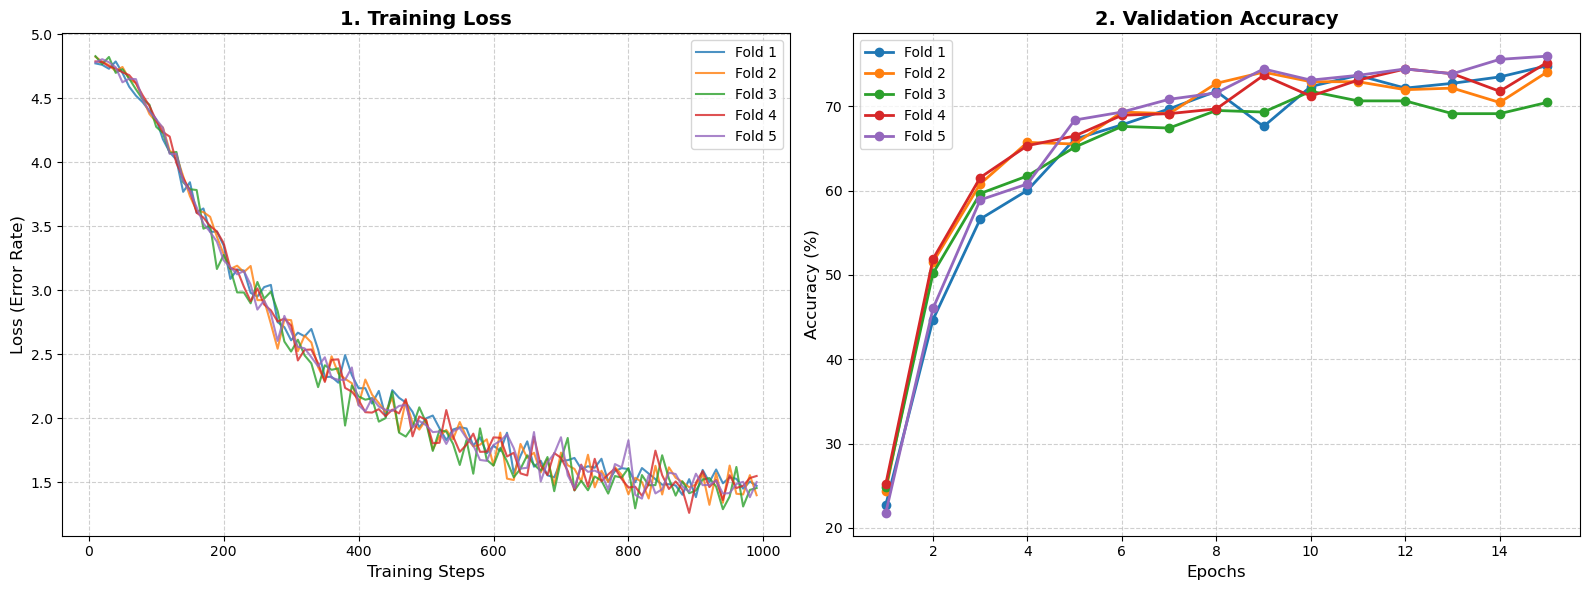

In [ ]:
plt.figure(figsize=(16, 6))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)

folds = 5
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i in range(1, folds + 1):
    fold_dir = f"./garbage_model_fold_{i}"
    
    if not os.path.exists(fold_dir):
        print(f"Could not find folder: {fold_dir}")
        continue

    # logs inside 'checkpoint-XXX' folders
    checkpoints = [d for d in os.listdir(fold_dir) if d.startswith("checkpoint")]
    if not checkpoints:
        print(f"No checkpoints found in {fold_dir}")
        continue

    checkpoints.sort(key=lambda x: int(x.split("-")[1]))
    latest_checkpoint = checkpoints[-1]
    
    state_path = os.path.join(fold_dir, latest_checkpoint, "trainer_state.json")
    
    if os.path.exists(state_path):
        with open(state_path, "r") as f:
            state = json.load(f)
            
        log_history = state["log_history"]
        
        # Loss for every 10 steps (logging_steps=10)
        train_steps = [log["step"] for log in log_history if "loss" in log]
        train_loss = [log["loss"] for log in log_history if "loss" in log]
        
        # Accuracy per each epoch
        eval_epochs = [log["epoch"] for log in log_history if "eval_accuracy" in log]
        eval_acc = [log["eval_accuracy"] * 100 for log in log_history if "eval_accuracy" in log] 
    
        ax1.plot(train_steps, train_loss, color=colors[i-1], alpha=0.8, label=f"Fold {i}")
        ax2.plot(eval_epochs, eval_acc, color=colors[i-1], marker='o', linewidth=2, label=f"Fold {i}")

# Training Loss
ax1.set_title("1. Training Loss", fontsize=14, fontweight='bold')
ax1.set_xlabel("Training Steps", fontsize=12)
ax1.set_ylabel("Loss (Error Rate)", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Validation Accuracy 
ax2.set_title("2. Validation Accuracy", fontsize=14, fontweight='bold')
ax2.set_xlabel("Epochs", fontsize=12)
ax2.set_ylabel("Accuracy (%)", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

In [18]:
from transformers.utils.notebook import NotebookProgressCallback

In [19]:
best_model = AutoModelForImageClassification.from_pretrained("./best_garbage_classifier")
best_processor = AutoImageProcessor.from_pretrained("./best_garbage_classifier")

test_prep = test.with_transform(val_transforms)

test_args = TrainingArguments(
    output_dir="./final_test_results",
    remove_unused_columns=False, 
    per_device_eval_batch_size=16,
    report_to="none" 
)

# Short evaluation
final_trainer = Trainer(
    model=best_model,
    args=test_args,
    data_collator=collate_fn,
    eval_dataset=test_prep,
    processing_class=best_processor,
    compute_metrics=compute_metrics,
)

final_trainer.remove_callback(NotebookProgressCallback)
print(f"Testing against {len(test_prep)} unseen vault images")
final_results = final_trainer.evaluate()
final_accuracy = final_results['eval_accuracy'] * 100
print(f"\n========================================")
print(f"Final test vault accuracy: {final_accuracy:.2f}%")


Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

Testing against 467 unseen vault images


C:\Users\ydmar\AppData\Roaming\Python\Python312\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Final test vault accuracy: 75.59%


## Setup and training for the higher image resolution (448x448)

In [23]:
image_processor = AutoImageProcessor.from_pretrained(model_name)
image_processor.size = {"height": 448, "width": 448}

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_accuracies = [] 
best_overall_accuracy = 0.0  
best_fold = 0
oof_preds = []
oof_labels = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(all_numerical_labels)), all_numerical_labels)):
    print(f"\n================================")
    print(f"       STARTING FOLD {fold + 1}/{n_splits}")
    print(f"================================")

    # Create  train/val subsets for this round
    fold_train_data = cv_train.select(train_idx).with_transform(train_transforms)
    fold_val_data = cv_train.select(val_idx).with_transform(val_transforms)

    
    model = AutoModelForImageClassification.from_pretrained(
        model_name,
        num_labels=len(labels), # num_labels is set to the number of classes in our dataset
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True  # allows loading pretrained weights even if the classifier head size doesn’t match your number of classes
    )

    # Setup Trainer for this fold
    training_args = TrainingArguments(
        output_dir=f"./garbage_model_448_fold_{fold + 1}", 
        remove_unused_columns=False, 
        eval_strategy="epoch", 
        save_strategy="epoch", 
        learning_rate=5e-5,
        per_device_train_batch_size=8, # reduced from 16
        gradient_accumulation_steps=4,  # reduced from 4
        per_device_eval_batch_size=8,   # reduced from 16
        num_train_epochs=15,      
        warmup_ratio=0.1, 
        logging_steps=10, 
        load_best_model_at_end=True,
        metric_for_best_model="accuracy"
    )


    trainer = Trainer(
        model=model,
        args=training_args,
        data_collator=collate_fn,
        train_dataset=fold_train_data,
        eval_dataset=fold_val_data,
        processing_class=image_processor,
        compute_metrics=compute_metrics,
    )
    trainer.train() # Train the Fold
    
    # Get final validation score per fold
    prediction_output = trainer.predict(fold_val_data)
    fold_acc = prediction_output.metrics['test_accuracy'] 
    fold_accuracies.append(fold_acc)
    print(f"\n>>> Fold {fold + 1} Accuracy: {fold_acc * 100:.2f}%\n")

    # Grab the winning guesses (argmax) and the true answers
    batch_preds = np.argmax(prediction_output.predictions, axis=1)
    batch_labels = prediction_output.label_ids
    
    # Store them in our global OOF lists
    oof_preds.extend(batch_preds)
    oof_labels.extend(batch_labels)

    if fold_acc > best_overall_accuracy:
        print(f"Best 448px model so far found in Fold {fold + 1} (Accuracy: {fold_acc * 100:.2f}%). Saving...")
        best_overall_accuracy = fold_acc
        best_fold = fold + 1
        trainer.save_model("./model_448px_experiment")
        image_processor.save_pretrained("./model_448px_experiment")

    # Free up computer memory before starting the next fold
    del model, trainer, training_args
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    

print("\n================================")
print("      CROSS-VALIDATION COMPLETE")
print("================================")
for i, acc in enumerate(fold_accuracies):
    print(f"Fold {i + 1}: {acc * 100:.2f}%")
print(f"\nAverage Accuracy across all {n_splits} folds: {np.mean(fold_accuracies) * 100:.2f}%")
print(f"Standard Deviation: ±{np.std(fold_accuracies) * 100:.2f}%")

print(f"\nThe best model was Fold {best_fold} with {best_overall_accuracy * 100:.2f}% accuracy.")
print("It has been saved to the folder: './model_448px_experiment'")


       STARTING FOLD 1/5


You passed `num_labels=11` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

EfficientNetForImageClassification LOAD REPORT from: google/efficientnet-b0
Key               | Status   |                                                                                             
------------------+----------+---------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 1280]) vs model:torch.Size([11, 1280])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([11])            

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
C:\Users\ydmar\AppData\Roaming\Python\Python312\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(load

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
# Fixing how to read the data (beginning of the document)
# Correlation matrix of OOF predictions
# Other related eda
# applying on the test dataset 
# test on other random images


In [ ]:
# WHat else we can do? 
# 1) Test with real examples of the garbage (test our model, good example plastic and glass and current recycling initiatives in Poland)
# 2) Try a different pretrained model (ResNet, ViT, or attached below huggingface model by link) and compare results
# https://huggingface.co/prithivMLmods/Trash-Net\
# Execute the following model as a comparison with our trained model 

Resources: <br>
1. Materials from "Image Recognition" lab classes by...
2. https://huggingface.co/transformers/v3.0.2/model_doc/auto.html <br>
3. https://huggingface.co/docs/transformers/model_doc/auto <br>
4. https://huggingface.co/datasets/viola77data/recycling-dataset <br>
5. https://huggingface.co/google/efficientnet-b0 <br>
6. https://github.com/tensorflow/tpu/blob/master/models/official/efficientnet/README.md <br>
7. https://huggingface.co/docs/transformers/main_classes/trainer
